Hey there! This is a minimal working example of using this package to compute the Onsager transport coefficients (and other properties that can be derived from them) for amorphous (or liquid-like) solids. 

In [1]:
from py_oats import *
from py_oats.plotter.transport import *

To begin, read in the trajectory file using the `TrajectoryData` class. You'll have to specify certain metadata (time step, frequnecy at which data was stored, temperature) when using this method. 

In [2]:
data = TrajectoryData.read("YAlO3_1500.0K.dump", time_step=2, step_skip=1000, temperature=1500)

This class reads in the trajectory (LAMMPS dumps, VASP XDATCARs and ase trajecotry objects are currently supported), unwraps coordinates and processes it into a format ready for analysis. 

To analyze transport, we'll use the `TransportAnalyzer` class:

In [3]:
analyzer = TransportAnalyzer(data)
analyzer.analyze()

And just like that, we're done! The whole i/o + analysis ops should take ~seconds-minutes on a laptop, depending on how big the trajectory is. We can now access the transport properties:

In [4]:
print("The fitted transport tensor is:")
print(analyzer.L_tensor)
print("The self-transport tensor can also be accessed as:")
print(analyzer.L_tensor_self)
print("The distinct transport tensor can also be accessed as:")
print(analyzer.L_tensor_dis)
print("The mapping of the species to the index of the transport tensor is:")
print(analyzer.mapping) #So here the L01 component is the correlated transport of Y wrt Al

The fitted transport tensor is:
[[ 1.02639462e+16  2.21884664e+14 -5.74500469e+16]
 [ 2.21884664e+14 -8.65285326e+14  2.09654251e+14]
 [-5.74500469e+16  2.09654251e+14  3.19139761e+17]]
The self-transport tensor can also be accessed as:
[[2.57380041e+16 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 3.61384202e+16 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.30220650e+17]]
The distinct transport tensor can also be accessed as:
[[-1.54740579e+16  2.21884664e+14 -5.74500469e+16]
 [ 2.21884664e+14 -3.70037055e+16  2.09654251e+14]
 [-5.74500469e+16  2.09654251e+14 -1.10808895e+16]]
The mapping of the species to the index of the transport tensor is:
{'Y': 0, 'Al': 1, 'O': 2}


So the (0, 0)th element of the transport tensor corresponds to the Y-Y coefficient, and so on. If you instead want the conventional "Einstein" diffusivity (or the self-diffusion coefficient), use:

In [5]:
analyzer.get_diffusivity(0) # Diffusivity of species 0

47662970614246.266

To see the quality of the transport coefficient's fits:

In [6]:
analyzer.fit_dicts_self # A dictionary of fit parameters for each species

array([[{'fit_err': 4.176271240433332e-06, 'slope_err': 0.12864579027158374, 'interval': [50, 450]},
        0, 0],
       [0,
        {'fit_err': 1.6978742423671408e-05, 'slope_err': 0.09322766985808417, 'interval': [50, 450]},
        0],
       [0, 0,
        {'fit_err': 7.48798177149447e-05, 'slope_err': 0.04304352337103967, 'interval': [50, 450]}]],
      dtype=object)

In [7]:
analyzer.fit_dicts # A dictionary of fit parameters for each species

array([[{'fit_err': 1.6602623963474884e-05, 'slope_err': 0.04781358212407427, 'interval': [50, 450]},
        {'fit_err': 2.9002180688927234e-05, 'slope_err': 1000000.0, 'interval': [50, 450]},
        {'fit_err': 0.00011480284154325121, 'slope_err': 1000000.0, 'interval': [50, 450]}],
       [{'fit_err': 2.9002180688927234e-05, 'slope_err': 1000000.0, 'interval': [50, 450]},
        {'fit_err': 3.6099559815201595e-05, 'slope_err': 0.4061827056607825, 'interval': [50, 450]},
        {'fit_err': 0.0001853959541988417, 'slope_err': 1000000.0, 'interval': [50, 450]}],
       [{'fit_err': 0.00011480284154325121, 'slope_err': 1000000.0, 'interval': [50, 450]},
        {'fit_err': 0.0001853959541988417, 'slope_err': 1000000.0, 'interval': [50, 450]},
        {'fit_err': 0.0008278825976462775, 'slope_err': 0.027749900417844198, 'interval': [50, 450]}]],
      dtype=object)

The correlation functions can also be plotted. The fitting functions try their best to fit a "line" (i.e., a linear curve) to each of these, but the numbers we get are meaningful only when such a fit is even possible. 

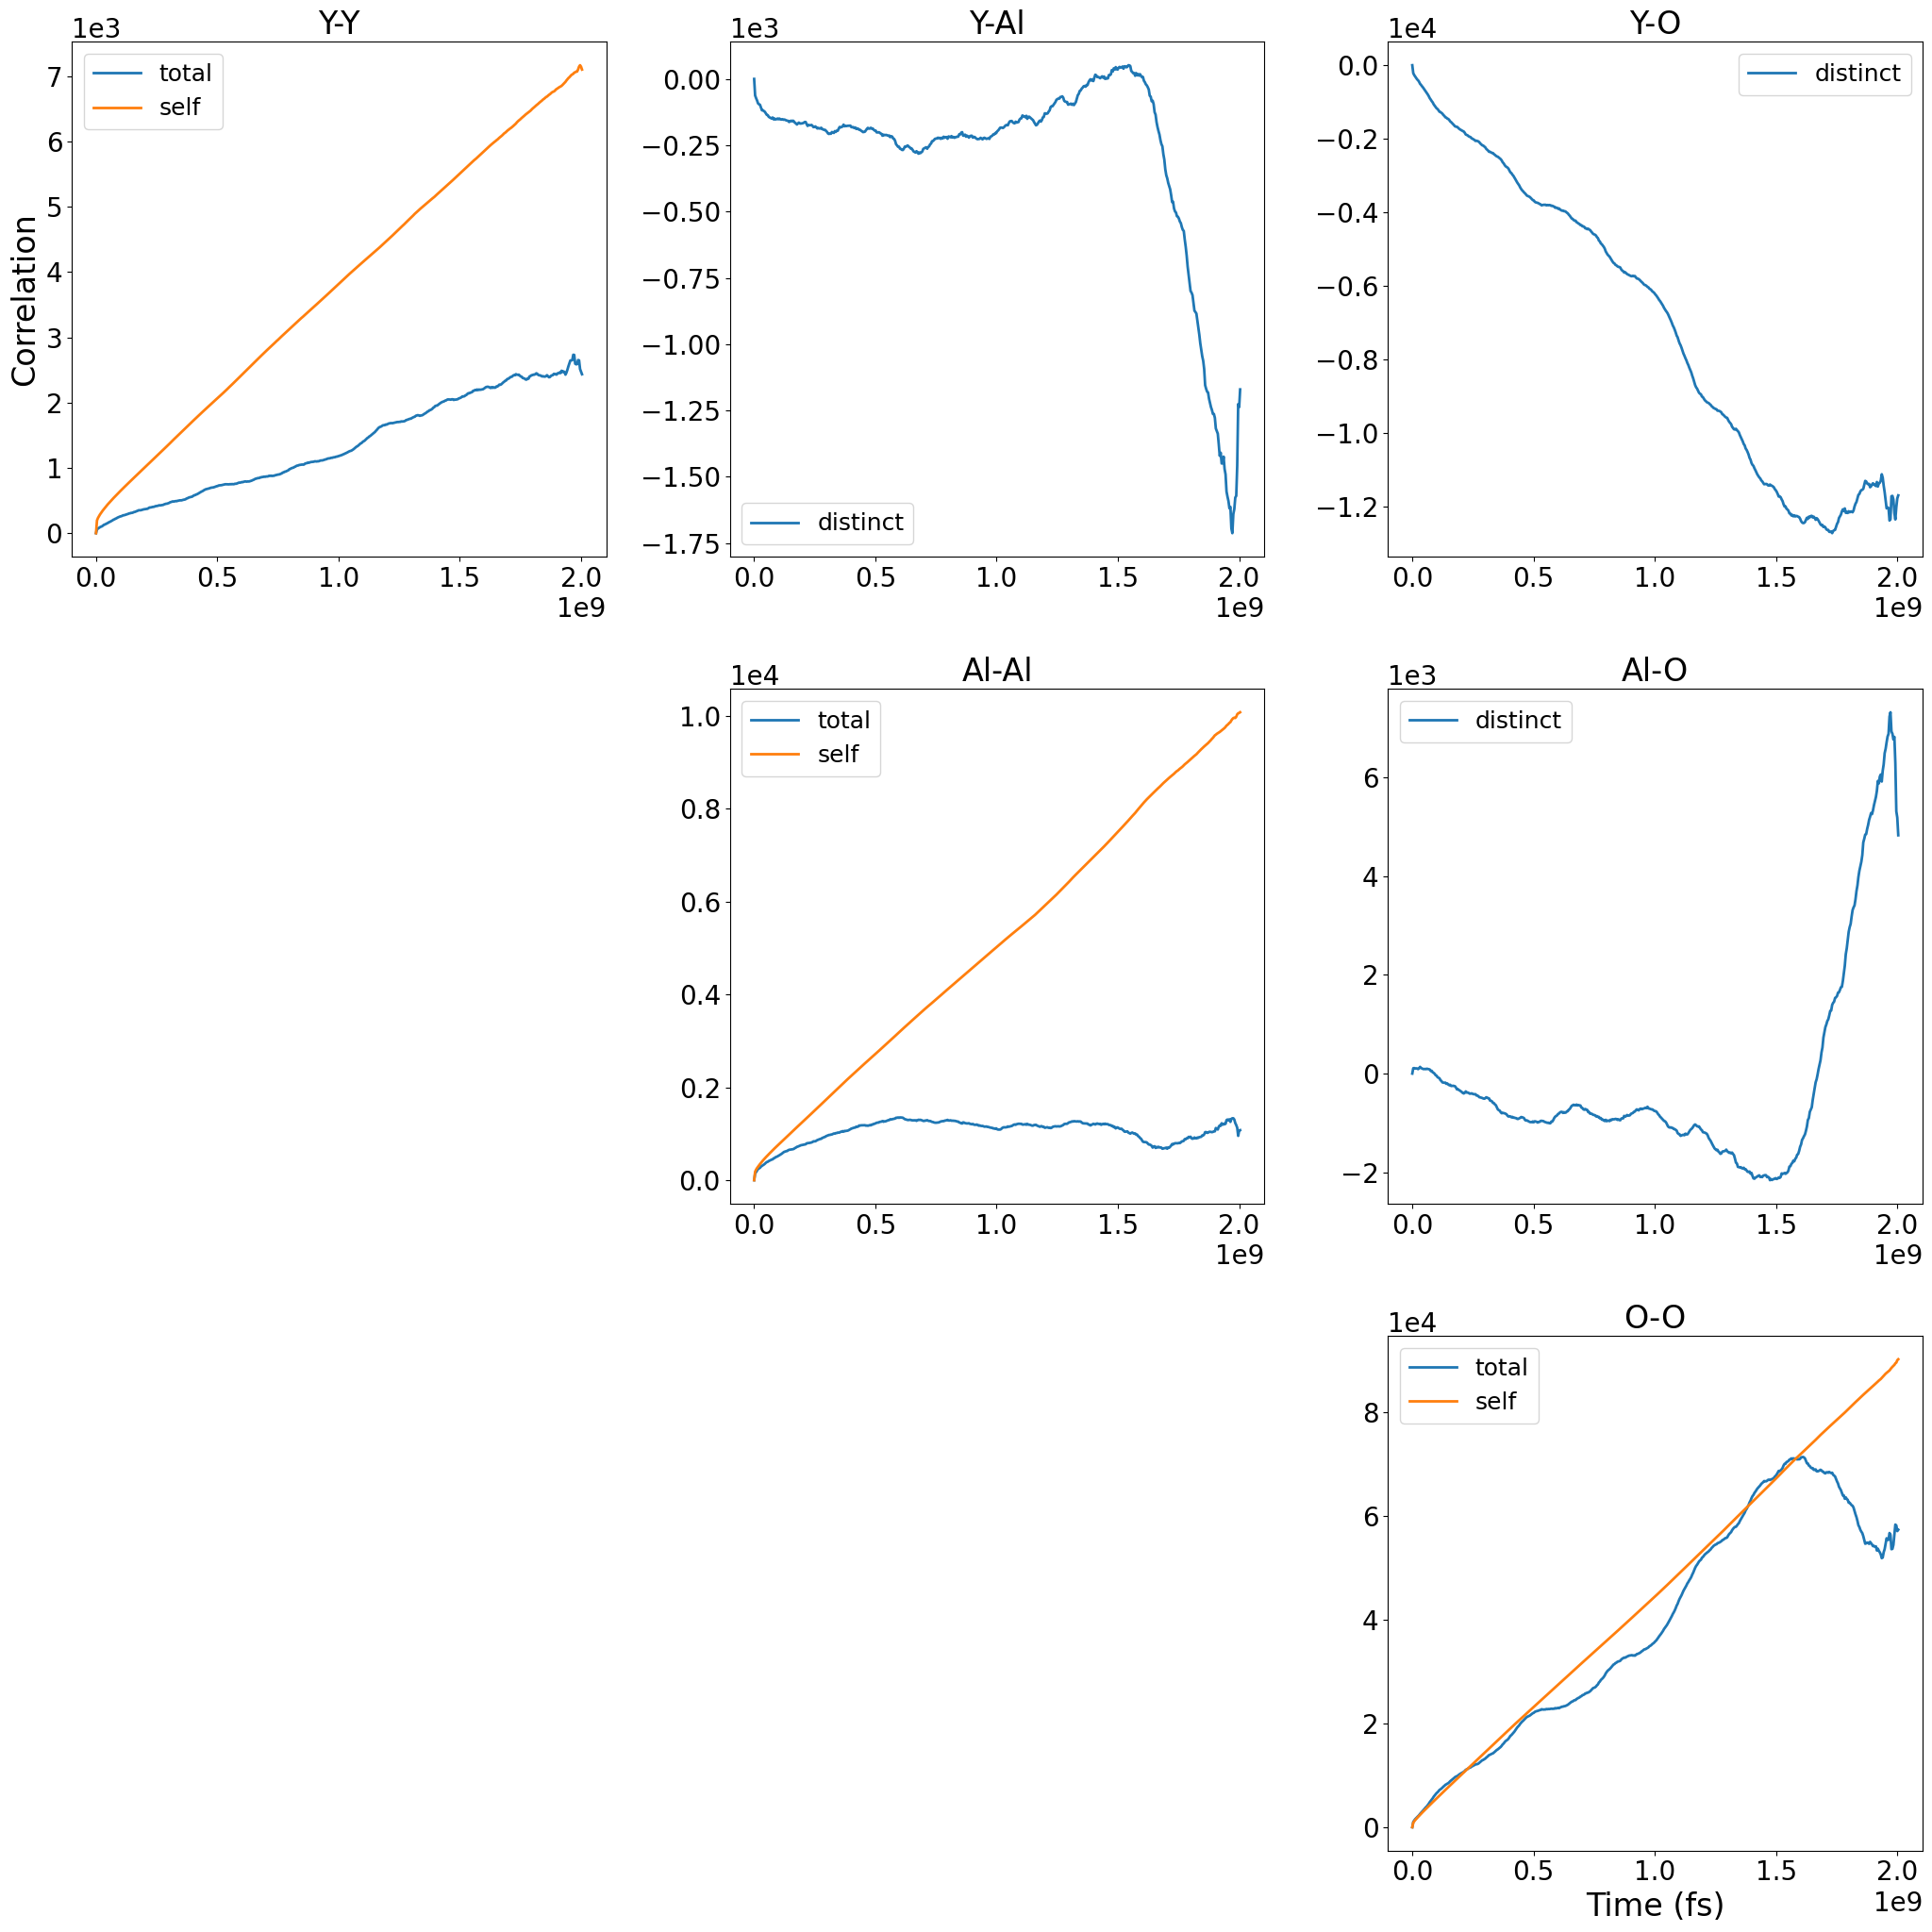

In [8]:
fig = plot_all_correlations(analyzer)

As per the above the plot, we can trust the slopes that would be fit to the self-components for all our specie (which is great!), and the Y-Y and Al-Al net coefficients. There is often a numerical noise induced by the fourier transform in the first and last tenths of the correlation function, and so even though it looks a bit wonky for the O-O net coefficient, the slope fit should be pretty good. I would be wary of using the coefficients fit for the Y-Al, Y-O and Al-O coefficients though, and getting a longer trajectory (or bigger system) to fit these is probably a good idea. The trajectory above is only 100ps long with a size of 2700 atoms, which explains the lack of statistics for the cross-coefficients. Obviously, the code examines the quality of fits in a quantitative way and throws a warning when the fit is exceptionally poor. 

Finally, to store the outputs of an analysis in a serializable format (super useful when dealing with a large repository of calculations that need to be store in a database), use the `TransportDoc` object:

In [5]:
from py_oats.schemas.transport import TransportDoc
doc = TransportDoc.from_analyzer(analyzer)
print('The attributes of the TransportDoc object are:')
print(list(doc.__dict__.keys()))
td_serialized = doc.as_dict() # serialize the TransportDoc object
td_deserialized = TransportDoc.from_dict(td_serialized) # deserialize the TransportDoc object

The attributes of the TransportDoc object are:
['composition', 'reduced_formula', 'species', 'L_tensor', 'L_tensor_self', 'L_tensor_dis', 'diffusivity', 'temperature', 'volume', 'num_atoms', 'mapping', 'correlation_functions', 'fit_dicts', 'fit_dicts_self', 'times', 'time_step', 'step_skip']


This object stores all (useful) information that can be extracted from the analyzer object in a lightweight class, and provides convinient `as_dict` and `from_dict` methods. The plotting functions from earlier work with this class as input too! 

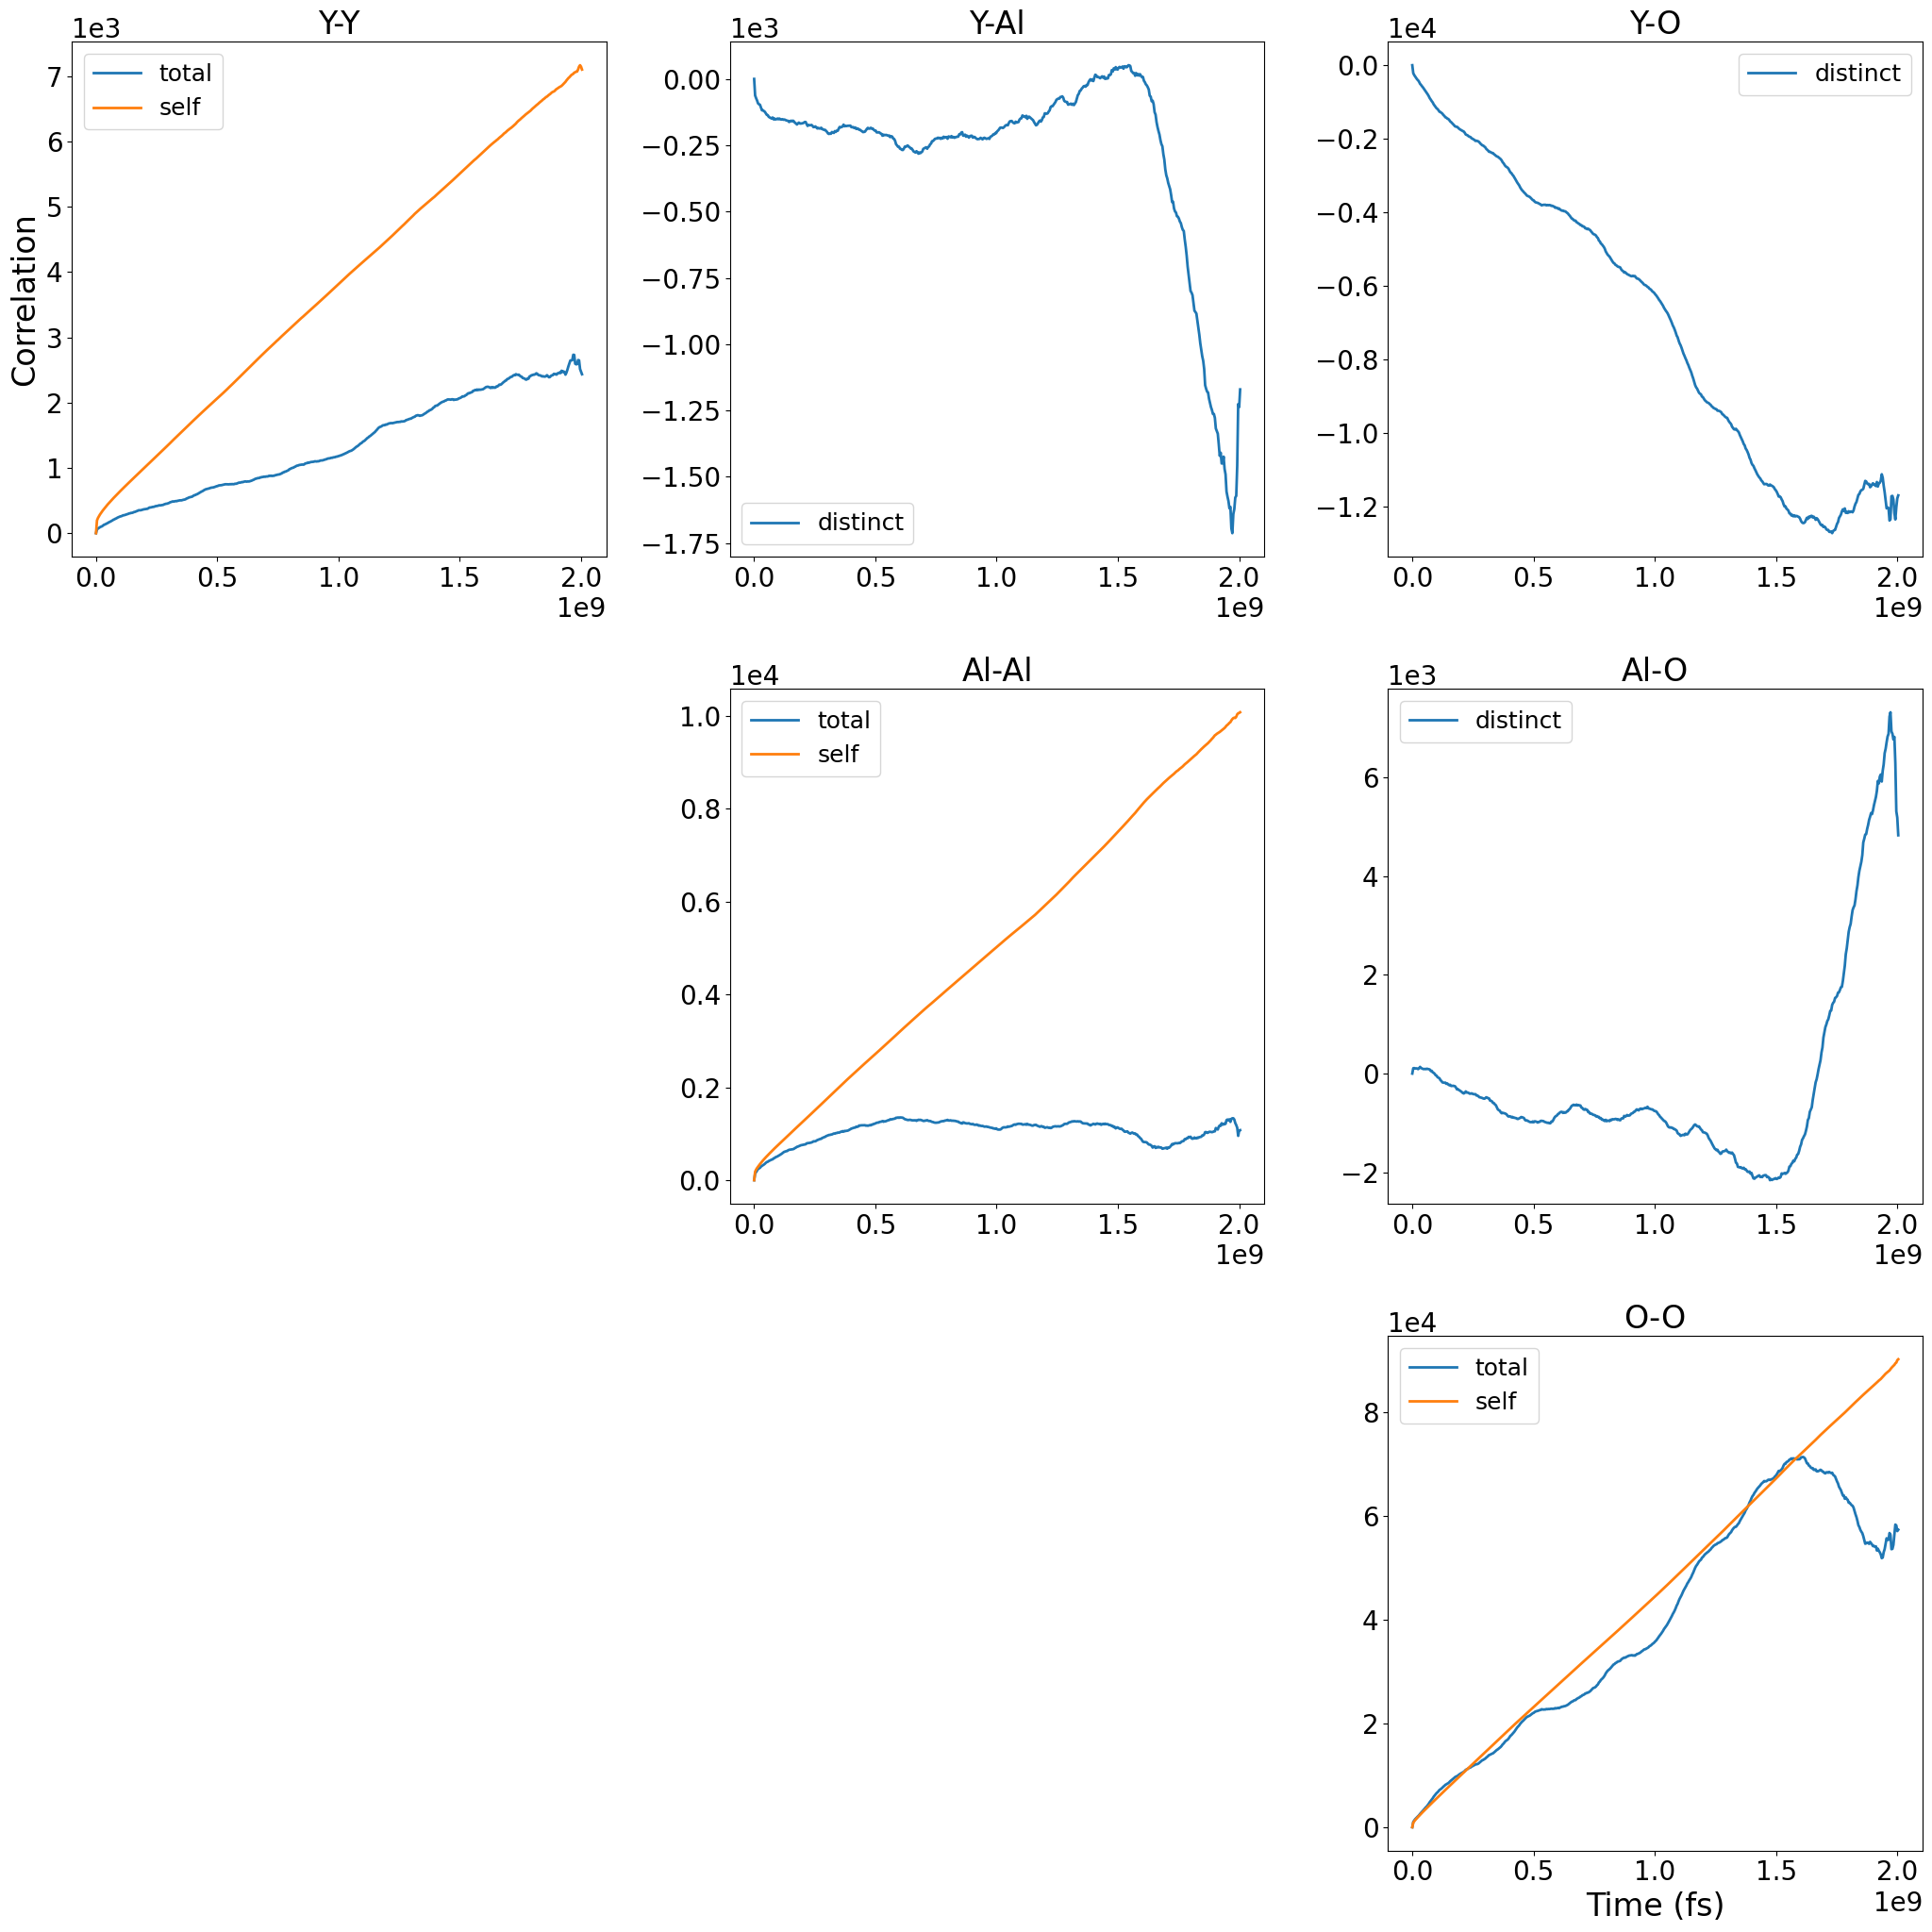

In [10]:
fig = plot_all_correlations(doc)

In [6]:
from monty.serialization import dumpfn, loadfn
dumpfn(doc, "transport_doc.json")

In [7]:
d = loadfn("transport_doc.json")

In [11]:
d

TransportDoc(composition='YAlO3', reduced_formula=None, species=['Y', 'Al', 'O'], L_tensor=array([[ 1.02639462e+16,  2.21884664e+14, -5.74500469e+16],
       [ 2.21884664e+14, -8.65285326e+14,  2.09654251e+14],
       [-5.74500469e+16,  2.09654251e+14,  3.19139761e+17]]), L_tensor_self=array([[2.57380041e+16, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 3.61384202e+16, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 3.30220650e+17]]), L_tensor_dis=array([[-1.54740579e+16,  2.21884664e+14, -5.74500469e+16],
       [ 2.21884664e+14, -3.70037055e+16,  2.09654251e+14],
       [-5.74500469e+16,  2.09654251e+14, -1.10808895e+16]]), diffusivity={'Y': 47662970614246.266, 'Al': 66923000314038.445, 'O': 203839907398115.62}, temperature=1500.0, volume=3.445072416306803e-20, num_atoms=2700, mapping={'Y': 0, 'Al': 1, 'O': 2}, correlation_functions={'Y-Y': {'total': array([2.38418579e-07, 5.77231793e+01, 7.02992070e+01, 8.05144724e+01,
       9.04993774e+01, 9.84081355e+01, 1.03